In [10]:
import argparse
import sys
import time
from collections import deque

import cv2
import numpy as np

WINDOW = "PennAir"
DEFAULT = "PennAir 2024 App Dynamic.mp4"

# Detector parameters
KERNEL_SIZE = 7
ERROR_THRESHOLD = 2
AREA_THRESHOLD = 1e3
DILATION_SIZE = KERNEL_SIZE//2-1

F_x = 2564.3186869 # px
F_y = 2569.70273111 # px
x_o = 5 # inches
x_circle = 104.2163692827433
z_o = F_x*x_o/x_circle


def image_to_world(x_i, y_i):
    x_o = z_o * x_i / F_x
    y_o = z_o * y_i / F_y
    return (x_o, y_o)

# from plane_fit.ipynb
# add a dilation step to fix the kernel clipping on sides
def planar_threshold_contours_masked(image, kernel_size, error_threshold, area_treshold):
    # plane fit
    K = kernel_size
    threshold = error_threshold

    assert K%2==1
    r = K//2

    n = K*K

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY).astype(np.float32)

    kOnes = np.ones(K, np.float64)

    # [-r, -r+1, ... 0 ... r-1, r]
    kRamp = np.arange(-r, r+1, dtype=np.float64)

    #sum(z_i) across the submatrix
    sz = cv2.sepFilter2D(gray, -1, kOnes, kOnes)
    szz = cv2.sepFilter2D(gray*gray, -1, kOnes, kOnes)

    #sum(x_i*z_i) across the submatrix
    sxz = cv2.sepFilter2D(gray, -1, kRamp, kOnes)

    #sum(z_i*y_i) across the submatrix
    syz = cv2.sepFilter2D(gray, -1, kOnes, kRamp)

    #sum(xx)=sum(yy) is independent of the image
    snn = K * np.dot(kRamp, kRamp)

    #z ~ a + bx + cy
    a = sz/n 
    b = sxz/snn
    c = syz/snn
    
    error_plane = szz - a*sz - b*sxz - c*syz
    error_plane_avg = np.sqrt(np.maximum(error_plane, 0)/n)
    mask = (error_plane_avg < threshold).astype(np.uint8)*255

    # gets rid of all "necks" by doing a 9x9 erode-then-dilate.
    # comes at the consequence of rounding corners, but worth for overall accuracy
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9)))

    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    cnts_filtered = [c for c in cnts if cv2.contourArea(c) > area_treshold]

    return cnts_filtered, error_plane_avg

def postprocess_dilate_contours(cnts_filled, dilation_px):
    cnts_dilated = []
    dilation = dilation_px

    for contour in cnts_filled:

        # instead of just dilating with cv2, we're restricting the dilation to a bounding box
        # of size K//2+1 to prevent the floodfill contour from overfilling onto the grass.
        x, y, w, h = cv2.boundingRect(contour)
        offset = np.array([x - dilation, y - dilation])

        roi = np.zeros((h + 2*dilation, w + 2*dilation), np.uint8)
        cv2.drawContours(roi, [contour - offset], -1, 255, cv2.FILLED)

        minkowski = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dilation*2+1, dilation*2+1))
        roi = cv2.dilate(roi, minkowski)

        out, _ = cv2.findContours(roi, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cnt_edited = max(out, key=cv2.contourArea) + offset
        cnts_dilated.append(cnt_edited)

    return cnts_dilated


def detect(image):
    cnts, _ = planar_threshold_contours_masked(image, KERNEL_SIZE, ERROR_THRESHOLD,
                                             AREA_THRESHOLD)
    return postprocess_dilate_contours(cnts, DILATION_SIZE)


# --- drawing ---------------------------------------------------------------

OUTLINE, CENTER, STATUS = (255, 0, 0), (0, 0, 255), (255, 255, 255)
FONT = cv2.FONT_HERSHEY_SIMPLEX


def centroid(contour):
    """Centre of mass of a contour, or None if it has zero area."""
    m = cv2.moments(contour)
    if m["m00"] == 0:
        return None
    return int(m["m10"] / m["m00"]), int(m["m01"] / m["m00"])


def annotate(img, contours, status=None):
    """Copy of `img` with each contour outlined and its centre marked."""
    vis = img.copy()
    cv2.drawContours(vis, list(contours), -1, OUTLINE, 2, cv2.LINE_AA)
    for contour in contours:
        point = centroid(contour)
        if point is None:
            continue
        cv2.drawMarker(vis, point, CENTER, cv2.MARKER_CROSS, 16, 2, cv2.LINE_AA)

        x_i, y_i = point[0], point[1]
        x_o, y_o = image_to_world(x_i, y_i)
        
        _text(vis, f"({x_o:.1f}, {y_o:.1f}, {z_o:.1f})",
              (x_i + 12, y_i - 12), 0.5, CENTER)
    if status:
        _text(vis, status, (12, 34), 0.7, STATUS)
    return vis


def _text(img, s, origin, scale, color):
    # Black pass first, so text stays readable over bright shapes and dark
    # background alike.
    cv2.putText(img, s, origin, FONT, scale, (0, 0, 0), 2, cv2.LINE_AA)
    cv2.putText(img, s, origin, FONT, scale, color, 2, cv2.LINE_AA)

In [11]:
def image(path):
    """The static image, as BGR uint8."""
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    return img


def frame(path, index=0):
    """One frame of a video by index.  Convenience for poking around."""
    cap = cv2.VideoCapture(path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, index)
    ok, img = cap.read()
    cap.release()
    if not ok:
        raise IOError(f"could not read frame {index} of {path}")
    return img


def frames(path, count=4):
    """`count` frames spread evenly across a video."""
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    out = []
    for i in np.linspace(0, max(total - 2, 0), count).astype(int):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ok, img = cap.read()
        if ok:
            out.append(img)
    cap.release()
    return out


def stream(path, count=None, start=0):
    """Yield frames sequentially, one at a time.  No seeking, no lookahead."""
    cap = cv2.VideoCapture(path)
    try:
        for i in range(start):
            if not cap.read()[0]:
                return
        n = 0
        while count is None or n < count:
            ok, img = cap.read()
            if not ok:
                return
            yield img
            n += 1
    finally:
        cap.release()

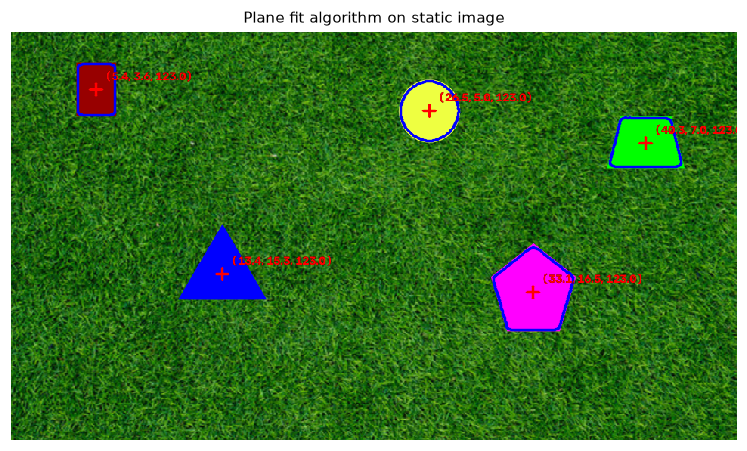

In [13]:
img = image("/home/taha/Code/clubs/PAiR/PennAir 2024 App Static.png")
cnts = detect(img)
show([annotate(img, cnts)], titles=["Plane fit algorithm on static image"])